# 1D AMT Synthetic Inversions (Halfspace + Layered + Position Change)

In [1]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives,utils,
)
from ipywidgets import widgets, interact
from pathlib import Path
from mtpy.core.mt_collection import MTCollection
mtc = MTCollection()
import mtpy as mt
import utm
import matplotlib.gridspec as gridspec
import scipy
import pandas as pd
from scipy.interpolate import griddata



#Solver for Mac
from pymatsolver import Mumps

matplotlib.rcParams['font.size'] = 14

### Reading Synthetic Data Files From Forward Model

In [2]:
dobs = np.load("Forward_Data/Observed_Forward_Model_Data_Original.npy")
dpred = np.load("Forward_Data/Observed_Forward_Model_Data_Reshaped.npy")

dobs_no_ore = np.load("Forward_Data/Observed_Forward_Model_Data_Original_no_ore.npy")
dpred_no_ore = np.load("Forward_Data/Observed_Forward_Model_Data_Reshaped_no_ore.npy")

### Defining Halfspace Mesh + Starting Model + Map

In [3]:
# Defining Mesh for Halfspace
layer_thick_halfspace = [1000]
n_layers_halfspace = 1
rho = 500

# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/500) * np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


### Bringing in used Frequencies and Geological Details

In [4]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 65,70,500]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,500,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data

#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304


### Setting up Simulation

In [5]:
#Setting up RX locations 
rx_loc_single = np.array([[0]])

#Receivers list
receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="real"),  #Only off diagonal components for 1D
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="imag"),

    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="real"),
    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="imag"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq)) # Setting sources as plane waves at each specified frequencies 

survey = nsem.survey.Survey(source_list) #Creating survey object with given sources form source_list

simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=[],
        sigmaMap=conductivity_halfspace_map
    )


### Viewing Data

`dobs_new` is created because the forward model simulation and the inversion simulation objects are different. They both take the data differently. Here we are setting it up for the `Simulation1DRecursive` simulation object and then viewing it.

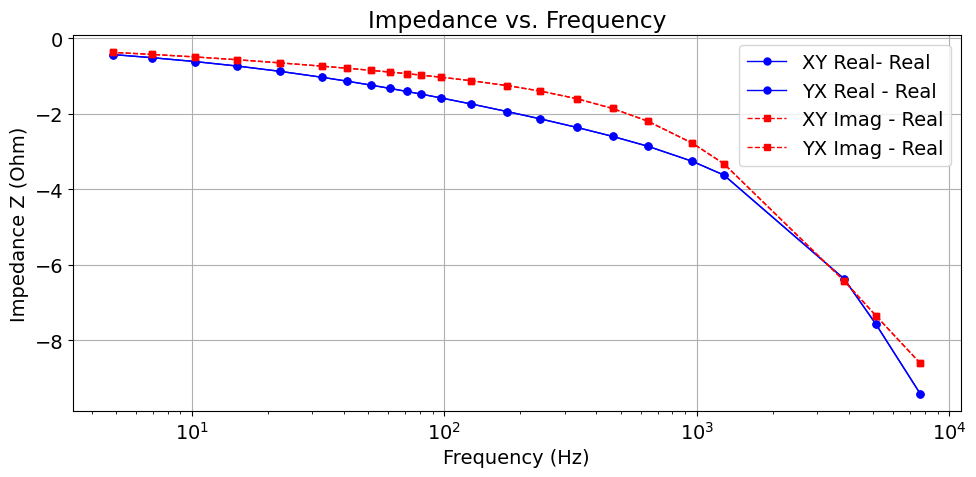

In [6]:
dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row


real_data_new = dobs_new.reshape(len(frequencies),4) # Reshaping to 23 rows and 4 columns

fig, ax = plt.subplots(1,1,figsize=(10, 5))

#Plotting Real Component XY and YX 
ax.semilogx(frequencies, real_data_new[:,0], "b-o", lw=1, ms=5, label = 'XY Real- Real')
ax.semilogx(frequencies, real_data_new[:,2], "b-o", lw=1, ms=5, label = 'YX Real - Real')

#Pting Imag Component XY and YX 
ax.semilogx(frequencies, real_data_new[:,1], "r--s", lw=1, ms=5, label = 'XY Imag - Real')
ax.semilogx(frequencies, real_data_new[:,3], "r--s", lw=1, ms=5, label = 'YX Imag - Real')

ax.grid()
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Impedance Z (Ohm)")
ax.set_title("Impedance vs. Frequency")
ax.legend

ax.legend()


fig.tight_layout()

plt.show()

### Data Misfit

In [7]:
#uncertainties = 0.05 * np.abs(dobs) * np.ones(np.shape(dobs))
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

In [8]:

h = np.r_[layer_thick_halfspace]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([h], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_x= 1e-6
reg_L2.alpha_s =reg_L2.alpha_x/(np.mean(layer_thicknesses)**2)



### Optimization

In [9]:
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

In [10]:
inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Halfspace Inversion!

In [11]:
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_hsp = conductivity_halfspace_map * recovered_halfspace_model_L2

output_dict = save_L2_hp.outDict

INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.43e+11  1.53e+04  0.00e+00  1.53e+04                                 
   1  1.43e+11  1.08e+04  1.28e-08  1.26e+04    8.18e+03      0              
   2  1.43e+11  9.86e+03  1.84e-08  1.25e+04    1.84e+03      0              
   3  1.43e+11  9.64e+03  1.99e-08  1.25e+04    4.39e+02      0              
   4  5.72e+10  5.41e+03  6.27e-08  9.00e+03    5.21e+03      0              
   5  5.72e+10  4.72e+03  7.35e-08  8.92e+03    1.32e+03      0              
   6  5.72e+10  4.57e+03  7.60e-08  8.92e+03    3.07e+02      0              
   7  2.29e+10  2.67e+03  1.23e-07  5.48e+03    4.06e+03      0              
   8  2.29e+10  2.61e+03  1.26e-07  5.48e+03    2.81e+02      0              
   9  2.29e+10  2.60e+03

### Results!

In [12]:
print("Conductivity halfspace: ", conductivities_hsp)
print("Resistivity halfspace: ", 1/conductivities_hsp)
rho_hsp_pred = 1/conductivities_hsp

Conductivity halfspace:  [0.0003045]
Resistivity halfspace:  [3284.06191818]


### Plotting Tikhonov Curves (L-curves)

In [13]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

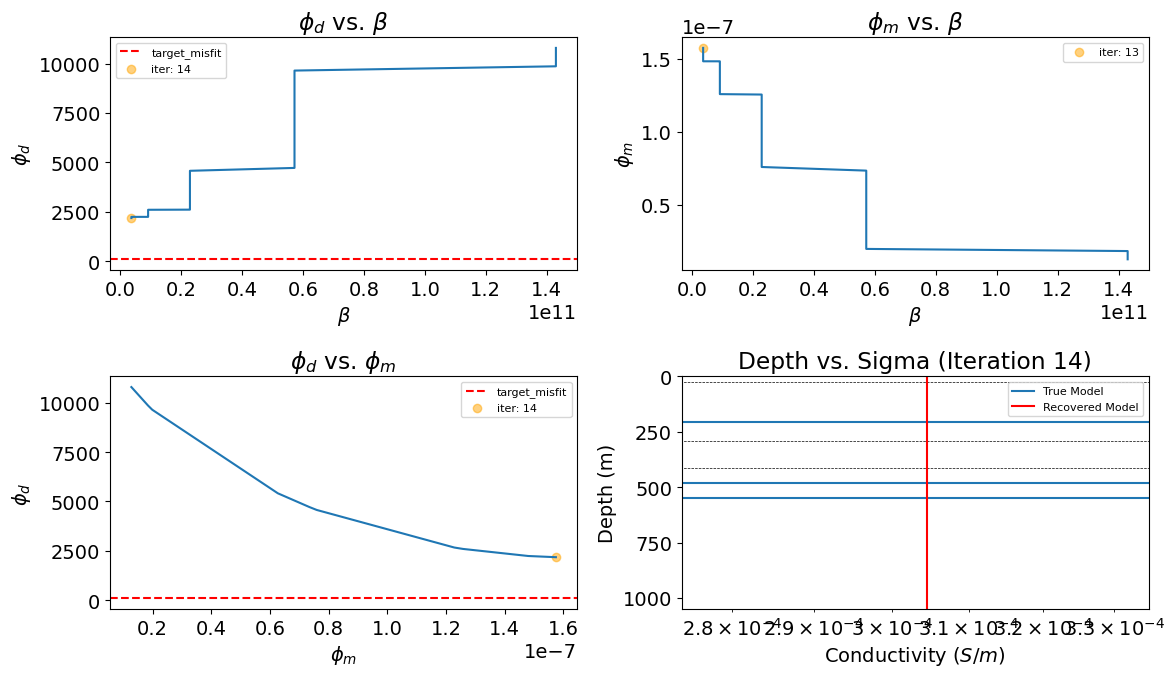

In [14]:
fig, ax = plt.subplots(2,2, figsize = (12,7))

#######################
iteration = 13         # --> Moving the iteration for the inversion
#######################

#Plotting L-cuves!


ax[0][0].plot(betas, phi_ds)
ax[0][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[0][0].scatter(betas[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[0][0].legend(fontsize = 8)
ax[0][0].set_xlabel(r"$\beta$")
ax[0][0].set_ylabel('$\phi_d$')
ax[0][0].set_title(r'$\phi_d$ vs. $\beta$ ')


ax[0][1].plot(betas, phi_ms)
ax[0][1].scatter(betas[iteration], phi_ms[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration}")
ax[0][1].legend(fontsize = 8)
ax[0][1].set_xlabel(r'$\beta$')
ax[0][1].set_ylabel('$\phi_m$')
ax[0][1].set_title(r'$\phi_m$ vs. $\beta$ ')



ax[1][0].plot(phi_ms, phi_ds)
ax[1][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[1][0].scatter(phi_ms[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[1][0].legend(fontsize = 8)
ax[1][0].set_xlabel('$\phi_m$')
ax[1][0].set_ylabel('$\phi_d$')
ax[1][0].set_title('$\phi_d$ vs. $\phi_m$')



#Obtaining the model for the specified iteration
iteration_conductivity_ml = conductivity_halfspace_map * output_dict[iteration + 1]['m'] #* conductivity_halfspace_map



#Plotting True Vs recovered iteration specified
plot_1d_layer_model(layer_thicknesses, sigma, label = 'True Model',ax = ax[1][1], show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, 1/rho_hsp_pred*np.ones_like(layer_thicknesses),c = 'r', label = 'Recovered Model', ax = ax[1][1])
ax[1][1].legend(fontsize= 8)
ax[1][1].set_xlabel(r"Conductivity ($S/m$)")
ax[1][1].set_title(f'Depth vs. Sigma (Iteration {iteration + 1})')


plt.tight_layout()

# Moving to a Multi-Layered Inversion using the recovered halfspace results as m0

## With Ore Body

In [15]:
# Defining Mesh for 7 layers
layer_thick = np.array([25, 180, 85, 125, 65, 70])   #m
rho = np.r_[2000., 2500., 4000., 4500., 8000., 500., 10000.] #ohm-m
n_layers_halfspace = len(rho)


# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/rho_hsp_pred)* np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=layer_thick,
        sigmaMap=conductivity_halfspace_map
    )

dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row



### Data Misfit
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

h = np.r_[layer_thick]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([np.ones(n_layers_halfspace)], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_x= 1e-6
reg_L2.alpha_s =reg_L2.alpha_x/(np.mean(layer_thicknesses)**2)


### Optimization
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Inversion !!!
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_ml = conductivity_halfspace_map * recovered_halfspace_model_L2
output_dict = save_L2_hp.outDict



INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  3.36e+09  2.18e+03  0.00e+00  2.18e+03                                 
   1  3.36e+09  8.36e+02  1.06e-07  1.19e+03    3.24e+03      0              
   2  3.36e+09  7.27e+02  1.32e-07  1.17e+03    4.75e+02      0              
   3  3.36e+09  7.13e+02  1.37e-07  1.17e+03    5.97e+01      0              
   4  1.34e+09  4.47e+02  2.53e-07  7.87e+02    9.62e+02      0              
   5  1.34e+09  4.21e+02  2.71e-07  7.85e+02    1.48e+02      0              
   6  1.34e+09  4.17e+02  2.74e-07  7.85e+02    1.91e+01      0              
   7  5.37e+08  2.62e+02  4.47e-07  5.02e+02    6.00e+02      0              
   8  5.37e+08  2.47e+02  4.73e-07  5.01e+02    9.87e+01      0              
   9  5.37e+08  2.45e+02

In [16]:
np.round(1/conductivities_ml[::-1]), 1/sigma

(array([2599., 2648., 2393., 1952., 1913., 3936., 8645.]),
 array([ 2000.,  2500.,  4000.,  4500.,  8000.,   500., 10000.]))

In [17]:
results = {'True':1/sigma, 'Recovered':1/conductivities_ml[::-1], 'Delta': rho - 1/conductivities_ml[::-1]}
results = pd.DataFrame(results)
print('Results in S/m:')
results

Results in S/m:


,True,Recovered,Delta
0,2000.0,2599.475953,-599.475953
1,2500.0,2647.501471,-147.501471
2,4000.0,2393.056196,1606.943804
3,4500.0,1952.186410,2547.813590
4,8000.0,1913.433059,6086.566941
5,500.0,3935.915200,-3435.915200
6,10000.0,8644.811359,1355.188641


Text(0.5, 1.0, 'Depth vs. Sigma (Converged Solution)')

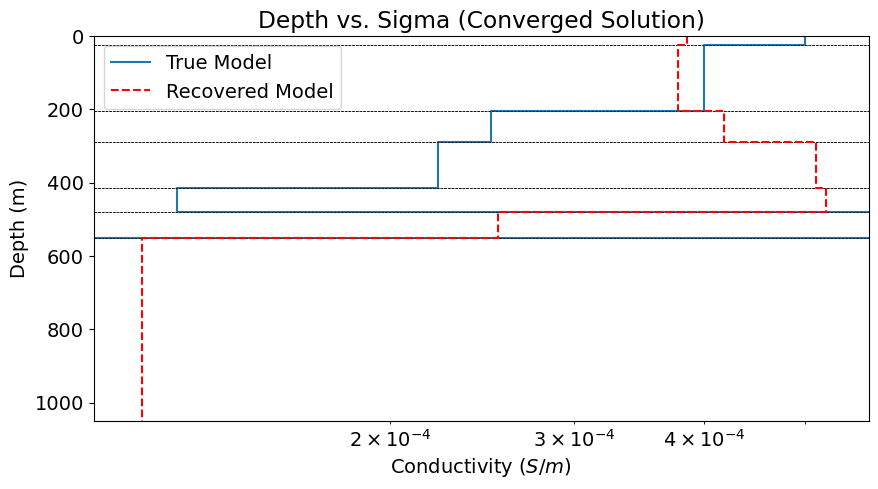

In [18]:
#Plotting True Vs recovered
fig , ax= plt.subplots(1,1,figsize=(10, 5))
plot_1d_layer_model(layer_thicknesses, 1/rho, label = 'True Model',ax = ax, show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, conductivities_ml[::-1],c = 'r', linestyle = '--', label = 'Recovered Model', ax = ax, show_layers=True)

ax.legend()
ax.set_xlabel(r"Conductivity ($S/m$)")
ax.set_title('Depth vs. Sigma (Converged Solution)')

### Plotting Tikhonov Curves (L-curves)

In [19]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

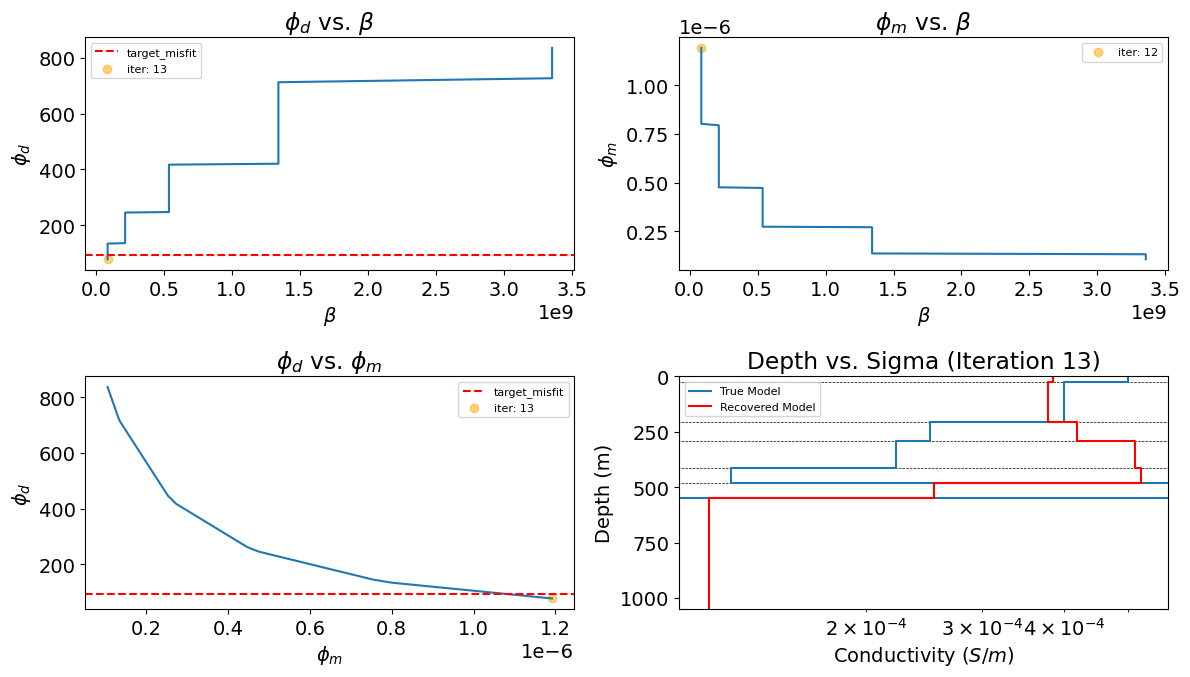

In [20]:
fig, ax = plt.subplots(2,2, figsize = (12,7))

#######################
iteration = 12        # --> Moving the iteration for the inversion
#######################

#Plotting L-cuves!


ax[0][0].plot(betas, phi_ds)
ax[0][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[0][0].scatter(betas[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[0][0].legend(fontsize = 8)
ax[0][0].set_xlabel(r"$\beta$")
ax[0][0].set_ylabel('$\phi_d$')
ax[0][0].set_title(r'$\phi_d$ vs. $\beta$ ')


ax[0][1].plot(betas, phi_ms)
ax[0][1].scatter(betas[iteration], phi_ms[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration}")
ax[0][1].legend(fontsize = 8)
ax[0][1].set_xlabel(r'$\beta$')
ax[0][1].set_ylabel('$\phi_m$')
ax[0][1].set_title(r'$\phi_m$ vs. $\beta$ ')



ax[1][0].plot(phi_ms, phi_ds)
ax[1][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[1][0].scatter(phi_ms[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[1][0].legend(fontsize = 8)
ax[1][0].set_xlabel('$\phi_m$')
ax[1][0].set_ylabel('$\phi_d$')
ax[1][0].set_title('$\phi_d$ vs. $\phi_m$')



#Obtaining the model for the specified iteration
iteration_conductivity_ml = conductivity_halfspace_map * output_dict[iteration + 1]['m'] #* conductivity_halfspace_map



#Plotting True Vs recovered iteration specified
plot_1d_layer_model(layer_thicknesses, 1/rho, label = 'True Model',ax = ax[1][1], show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, iteration_conductivity_ml[::-1],c = 'r', label = 'Recovered Model', ax = ax[1][1])
ax[1][1].legend(fontsize= 8)
ax[1][1].set_xlabel(r"Conductivity ($S/m$)")
ax[1][1].set_title(f'Depth vs. Sigma (Iteration {iteration + 1})')


plt.tight_layout()

## Without Ore Body (ie. Position Change)

INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.26e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  2.26e+09  1.10e+02  2.63e-07  7.06e+02    4.62e+03      0              
   2  2.26e+09  1.60e+02  2.33e-07  6.88e+02    5.45e+02      0              
   3  2.26e+09  1.63e+02  2.32e-07  6.88e+02    2.92e+01      0              
   4  9.05e+08  3.61e+01  3.15e-07  3.21e+02    7.05e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 5.2022e+01 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.7611e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 7.0467e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.0467e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter

,True,Recovered,Delta
0,2000.0,2457.991130,-457.991130
1,2500.0,2743.802245,-243.802245
2,4000.0,3283.468946,716.531054
3,4500.0,4202.232217,297.767783
4,8000.0,5465.480924,2534.519076
5,500.0,7128.826842,871.173158
6,10000.0,9290.126223,709.873777


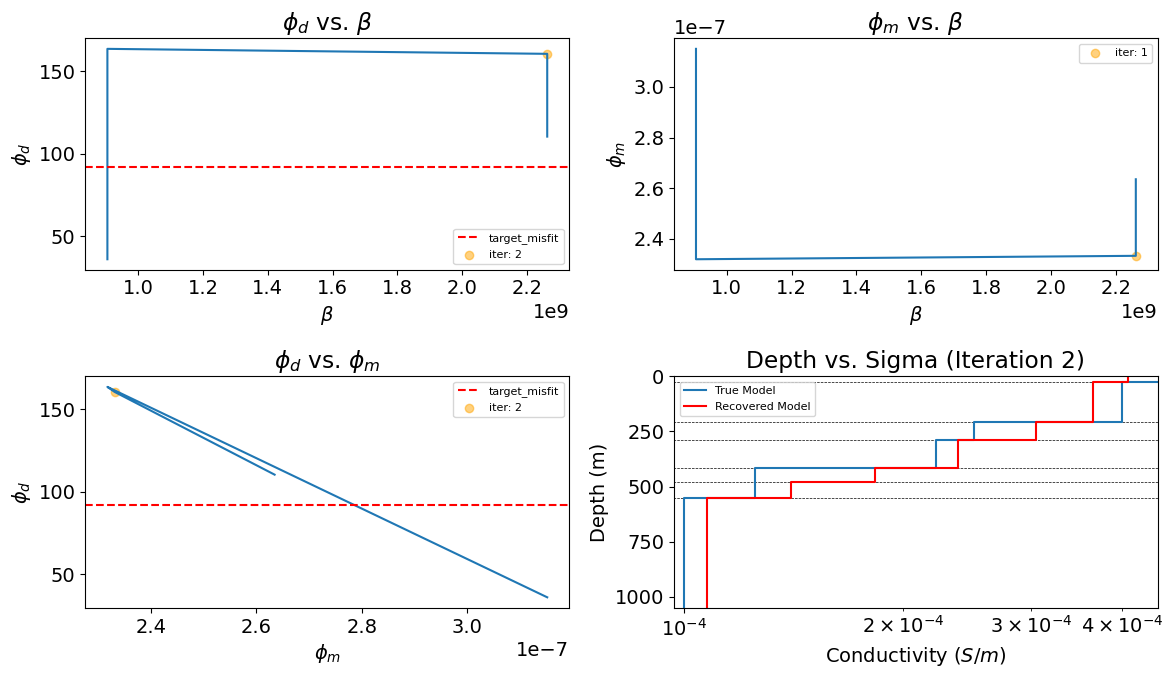

In [21]:

# Defining Mesh for 7 layers
n_layers_halfspace = len(rho)
rho = np.r_[2000., 2500., 4000., 4500., 8000., 8000., 10000.]

layer_thick = np.array([25, 180, 85, 125, 65, 70])


# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/rho_hsp_pred)* np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=layer_thick,
        sigmaMap=conductivity_halfspace_map
    )

dobs_new = [dpred_no_ore[:,0] , dpred_no_ore[:,1], dpred_no_ore[:,2]*-1 ,  dpred_no_ore[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row



### Data Misfit
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

h = np.r_[layer_thick]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([np.ones(n_layers_halfspace)], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_x= 1e-6
reg_L2.alpha_s =reg_L2.alpha_x/(np.mean(layer_thicknesses)**2)

### Optimization
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Inversion !!!
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_no_ore_ml = conductivity_halfspace_map * recovered_halfspace_model_L2
output_dict = save_L2_hp.outDict



# L Curves

target_misfit = dpred_no_ore.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']


fig, ax = plt.subplots(2,2, figsize = (12,7))

#######################
iteration = 1       # --> Moving the iteration for the inversion
#######################

#Plotting L-cuves!


ax[0][0].plot(betas, phi_ds)
ax[0][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[0][0].scatter(betas[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[0][0].legend(fontsize = 8)
ax[0][0].set_xlabel(r"$\beta$")
ax[0][0].set_ylabel('$\phi_d$')
ax[0][0].set_title(r'$\phi_d$ vs. $\beta$ ')


ax[0][1].plot(betas, phi_ms)
ax[0][1].scatter(betas[iteration], phi_ms[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration}")
ax[0][1].legend(fontsize = 8)
ax[0][1].set_xlabel(r'$\beta$')
ax[0][1].set_ylabel('$\phi_m$')
ax[0][1].set_title(r'$\phi_m$ vs. $\beta$ ')



ax[1][0].plot(phi_ms, phi_ds)
ax[1][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[1][0].scatter(phi_ms[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[1][0].legend(fontsize = 8)
ax[1][0].set_xlabel('$\phi_m$')
ax[1][0].set_ylabel('$\phi_d$')
ax[1][0].set_title('$\phi_d$ vs. $\phi_m$')





#Plotting True Vs recovered iteration specified
plot_1d_layer_model(layer_thicknesses, 1/rho, label = 'True Model',ax = ax[1][1], show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, conductivities_no_ore_ml[::-1],c = 'r', label = 'Recovered Model', ax = ax[1][1])
ax[1][1].legend(fontsize= 8)
ax[1][1].set_xlabel(r"Conductivity ($S/m$)")
ax[1][1].set_title(f'Depth vs. Sigma (Iteration {iteration + 1})')


plt.tight_layout()

results = {'True':1/sigma, 'Recovered':1/conductivities_no_ore_ml[::-1], 'Delta': rho - 1/conductivities_no_ore_ml[::-1]}
results = pd.DataFrame(results)
print('Results in S/m:')
results

### Defining L2 Sounding Inversion Function

In [22]:
#Defining Inversion Function

def L2_1D_Inversion(dpred, rho):

    """
    L2 Inversion For Soundings
    
    Inputs: Layer thicknesses
    
    Returns: layer conductivites

    """

    
    # Defining Mesh for 7 layers
    #rho = np.r_[2000., 2500., 4000., 4500., 8000., 500., 10000.] #ohm-m
    n_layers_halfspace = len(rho)
    layer_thick = np.array([25, 180, 85, 125, 65, 70])
    
    
    # Defining the mapping
    conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)
    
    m0 = np.log(1/rho_hsp_pred)* np.ones(n_layers_halfspace)
    
    # Reference model, same as starting 
    reference_conductivity_model = m0.copy()
    
    
    simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
            survey=survey,
            sigma = 1/rho,
            thicknesses=layer_thick,
            sigmaMap=conductivity_halfspace_map
        )
    
    dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
    dobs_new = np.array(dobs_new) # turning it to a numpy array
    dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row
    
    
    
    ### Data Misfit
    data_object = data.Data(survey,
                            dobs=dobs_new,
                            relative_error=0.05) # Using relative error instead of uncertainty
    dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                           data=data_object)
    
    ### Regularization
    
    h = np.r_[layer_thick]
    
    # Create regularization mesh
    regularization_mesh_hs = TensorMesh([np.ones(n_layers_halfspace)], "N")
    
    reg_L2 = regularization.WeightedLeastSquares(
            regularization_mesh_hs,
            length_scale_x=10.0,
            reference_model=reference_conductivity_model,
            reference_model_in_smooth=True
            )
    
    #Set regularization parameters:
    reg_L2.alpha_x= 1e-6
    reg_L2.alpha_s =reg_L2.alpha_x/(np.mean(layer_thicknesses)**2)
    
    ### Optimization
    opt_L2 = optimization.InexactGaussNewton(
        maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
    )
    
    ### Inversion Parameters
    
    inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)
    
    #Set inversion directives:
    update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
    starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
    beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
    target_misfit = directives.TargetMisfit(chifact=1.0)
    save_L2_hp = directives.SaveOutputDictEveryIteration()
    
    directives_list_L2 = [
        update_jacobi,
        starting_beta,
        beta_schedule,
        target_misfit,
        save_L2_hp
    ]
    
    ### Inversion !!!
    # Combine the inverse problem and the set of directives
    inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)
    
    # Run the inversion
    recovered_halfspace_model_L2 = inv_L2.run(m0)
    
    ## Get the recovered halfspace resistivity from model estimated
    conductivities_ml = conductivity_halfspace_map * recovered_halfspace_model_L2
    output_dict = save_L2_hp.outDict

    return conductivities_ml
    

### Creating Various Soundings using function with rectangular ore body

In [23]:
# Creating 21 total soundings where the ore body will be the 11th

n_soundings = 57
n_soundings_with_ore = 7

all_layer_thicknesses = []

for i in range(n_soundings):
    all_layer_thicknesses.append([25, 180, 85, 125, 65,70,500])



rho_ore = np.r_[2000., 2500., 4000., 4500., 8000., 500., 10000.]
rho_background  = np.r_[2000., 2500., 4000., 4500., 8000., 8000., 10000.]

all_rho = []

start_ore = (n_soundings - n_soundings_with_ore)// 2
end_ore = start_ore + n_soundings_with_ore

for i in range(n_soundings):
    if start_ore <= i < end_ore:
        all_rho.append(rho_ore.copy())
    else:
        all_rho.append(rho_background.copy())




Inversion_sigma = []
for ii, i in enumerate(range(n_soundings)):
    if start_ore <= i < end_ore:
        Inversion_sigma.append(L2_1D_Inversion(dpred, all_rho[ii]))
    else:
        Inversion_sigma.append(L2_1D_Inversion(dpred_no_ore, all_rho[ii]))



INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.07e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  2.07e+09  8.71e+01  2.79e-07  6.64e+02    4.62e+03      0              
------------------------- STOP! -------------------------
0 : |fc-fOld| = 2.8048e+03 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.4334e+00 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 4.6206e+03 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 4.6206e+03 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =      1
------------------------- DONE! -------------------------


INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.15e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  2.15e+09  9.72e+01  2.72e-07  6.83e+02    4.62e+03      0              


INFO: Directive TargetMisfit: Target data misfit is 92.0


...

   2  2.48e+09  1.85e+02  2.23e-07  7.37e+02    4.86e+02      0              
   3  2.48e+09  1.88e+02  2.22e-07  7.37e+02    2.78e+01      0              
   4  9.92e+08  4.24e+01  3.09e-07  3.48e+02    7.55e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 5.9198e+01 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.8674e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 7.5543e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.5543e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =      4
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.48e+09  3.47e+03  0.00e+00  3.47e+03                                 
 

INFO: Directive TargetMisfit: Target data misfit is 92.0


   4  9.92e+08  4.24e+01  3.09e-07  3.48e+02    7.56e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 5.9219e+01 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.8677e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 7.5557e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.5557e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =      4
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.91e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  1.91e+09  7.06e+01  2.93e-07  6.30e+02    4.62e+03      0              
------------------------- STOP! -------------------------
0 : |fc-fOld| = 2.838

INFO: Directive TargetMisfit: Target data misfit is 92.0
INFO: Directive TargetMisfit: Target data misfit is 92.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.96e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  1.96e+09  7.52e+01  2.89e-07  6.40e+02    4.62e+03      0              
------------------------- STOP! -------------------------
0 : |fc-fOld| = 2.8288e+03 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.4471e+00 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 4.6206e+03 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 4.6206e+03 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =      1
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   


### Creating 2D Interpolation:

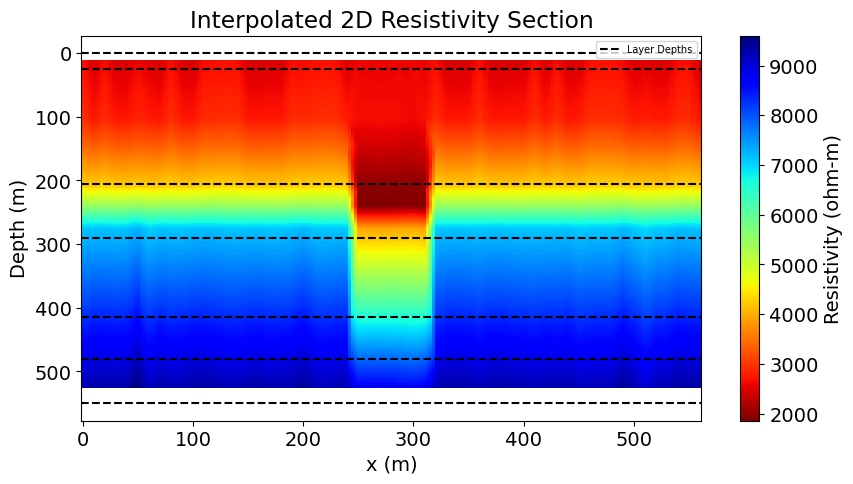

,True,Ore Sounding,Background Sounding
0,2000.0,2587.452789,2680.140582
1,2500.0,2663.292294,2928.594008
2,4000.0,2422.967208,3410.213893
3,4500.0,1952.392554,4277.000632
4,8000.0,1882.476376,5489.886080
5,8000.0,3908.578171,7119.393395
6,10000.0,8683.818839,9222.448710


In [24]:
#Survey Parameter
dx = 10 #m

#Creating an RX location starting at 0
rx_loc = np.arange(n_soundings) * dx   #m


layer_thicknesses = np.array([25, 180, 85, 125, 65, 70, 500])

#Computing layer depths
layer_depth = np.r_[0, np.cumsum(layer_thicknesses[:-1])]
#Computing Layer centers
layer_centers = (layer_depth + layer_thicknesses)/ 2



#Creating mesh for interpolation
X, Z = np.meshgrid(rx_loc, layer_centers, indexing='ij')
X = np.array(X)
Z = np.array(Z)
Inversion_rho = 1/np.array(Inversion_sigma)
Inversion_rho = Inversion_rho[:,::-1]
points = np.c_[X.ravel(), Z.ravel()]  
values = Inversion_rho.ravel()          
x_grid = np.linspace(rx_loc.min(), rx_loc.max(), 200)
z_grid = np.linspace(layer_centers.min(), layer_centers.max(), 200)

XI, ZI = np.meshgrid(x_grid, z_grid)

# 2D Interpolation 
rho_section = griddata(points,values, (XI, ZI), method='linear')


#Plotting results!
plt.figure(figsize=(10, 5))

plt.pcolormesh(XI, ZI, rho_section, cmap = 'jet_r')

#Plotting true layer depths
for i in layer_depth:
    plt.axhline(i, c = 'k', linestyle = '--')

plt.gca().invert_yaxis()
plt.colorbar(label='Resistivity (ohm-m)')
plt.xlabel('x (m)')
plt.ylabel('Depth (m)')
plt.title('Interpolated 2D Resistivity Section')
plt.legend(fontsize = 7, labels =['Layer Depths'], loc = 1)
plt.show()

ore_rho = Inversion_rho[25]
no_ore_rho = Inversion_rho[0]
rho

rhos_table = {'True':rho, 'Ore Sounding': ore_rho, 'Background Sounding': no_ore_rho}
pd.DataFrame(rhos_table)

### For comparison, 2D Interpolation of No Ore Data and Only Ore:

## No Ore 2D Interpolation

In [25]:
# Creating 21 total soundings where the ore body will be the 11th

n_soundings = 25

all_layer_thicknesses = []

for i in range(n_soundings):
    all_layer_thicknesses.append([25, 180, 85, 125, 65,70,500])



rho_ore = np.r_[2000., 2500., 4000., 4500., 8000., 500., 10000.]
rho_background  = np.r_[2000., 2500., 4000., 4500., 8000., 8000., 10000.]

all_rho = []

for i in range(n_soundings):
    all_rho.append(rho_background.copy())





Inversion_sigma = []
for ii, i in enumerate(range(n_soundings)):
        Inversion_sigma.append(L2_1D_Inversion(dpred_no_ore, all_rho[ii]))

#Survey Parameter
dx = 10 #m

#Creating an RX location starting at 0
rx_loc = np.arange(n_soundings) * dx   #m


layer_thicknesses = np.array([25, 180, 85, 125, 65, 70, 500])

#Computing layer depths
layer_depth = np.r_[0, np.cumsum(layer_thicknesses[:-1])]
#Computing Layer centers
layer_centers = (layer_depth + layer_thicknesses)/ 2



#Creating mesh for interpolation
X, Z = np.meshgrid(rx_loc, layer_centers, indexing='ij')
X = np.array(X)
Z = np.array(Z)
Inversion_rho = 1/np.array(Inversion_sigma)
Inversion_rho = Inversion_rho[:,::-1]
points = np.c_[X.ravel(), Z.ravel()]  
values = Inversion_rho.ravel()          
x_grid = np.linspace(rx_loc.min(), rx_loc.max(), 200)
z_grid = np.linspace(layer_centers.min(), layer_centers.max(), 200)

XI, ZI = np.meshgrid(x_grid, z_grid)

# 2D Interpolation 
rho_section = griddata(points,values, (XI, ZI), method='linear')


rh0_no_ore_example = Inversion_sigma[0]


INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.07e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  2.07e+09  8.78e+01  2.79e-07  6.65e+02    4.62e+03      0              
------------------------- STOP! -------------------------
0 : |fc-fOld| = 2.8035e+03 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.4326e+00 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 4.6206e+03 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 4.6206e+03 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =      1
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0


INFO: Directive TargetMisfit: Target data misfit is 92.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.30e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  2.30e+09  1.15e+02  2.61e-07  7.15e+02    4.62e+03      0              


INFO: Directive TargetMisfit: Target data misfit is 92.0


...

   1  2.38e+09  1.25e+02  2.55e-07  7.31e+02    4.62e+03      0              
   2  2.38e+09  1.74e+02  2.27e-07  7.15e+02    5.12e+02      0              
   3  2.38e+09  1.77e+02  2.26e-07  7.15e+02    2.84e+01      0              
   4  9.52e+08  3.95e+01  3.11e-07  3.36e+02    7.33e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 5.5930e+01 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.8200e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 7.3264e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.3264e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =      4
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
 

INFO: Directive TargetMisfit: Target data misfit is 92.0


   4  8.85e+08  3.47e+01  3.17e-07  3.15e+02    6.93e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 5.0362e+01 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.7352e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 6.9252e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 6.9252e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =      4
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.11e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  2.11e+09  9.17e+01  2.76e-07  6.73e+02    4.62e+03      0              
------------------------- STOP! -------------------------
0 : |fc-fOld| = 2.796

INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.43e+09  3.47e+03  0.00e+00  3.47e+03                                 
   1  2.43e+09  1.32e+02  2.51e-07  7.42e+02    4.62e+03      0              
   2  2.43e+09  1.79e+02  2.25e-07  7.26e+02    4.99e+02      0              
   3  2.43e+09  1.82e+02  2.24e-07  7.26e+02    2.81e+01      0              
   4  9.72e+08  4.09e+01  3.10e-07  3.42e+02    7.44e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 5.7564e+01 <= tolF*(1+|f0|) = 3.4697e+02
1 : |xc-x_last| = 1.8439e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 7.4410e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.4410e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter

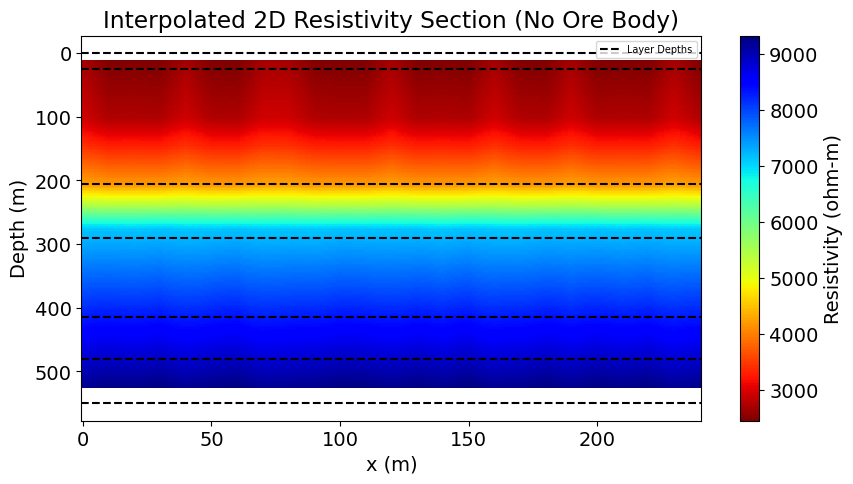

In [26]:
#Plotting results!
plt.figure(figsize=(10, 5))

plt.pcolormesh(XI, ZI, rho_section, cmap = 'jet_r')

#Plotting true layer depths
for i in layer_depth:
    plt.axhline(i, c = 'k', linestyle = '--')

plt.gca().invert_yaxis()
plt.colorbar(label='Resistivity (ohm-m)')
plt.xlabel('x (m)')
plt.ylabel('Depth (m)')
plt.title('Interpolated 2D Resistivity Section (No Ore Body)')
plt.legend(fontsize = 7, labels =['Layer Depths'], loc = 1)
plt.show()

## Only Ore 2D Interpolation

In [27]:
# Creating 21 total soundings where the ore body will be the 11th

n_soundings = 7

all_layer_thicknesses = []

for i in range(n_soundings):
    all_layer_thicknesses.append([25, 180, 85, 125, 65,70,500])



rho_ore = np.r_[2000., 2500., 4000., 4500., 8000., 500., 10000.]
rho_background  = np.r_[2000., 2500., 4000., 4500., 8000., 8000., 10000.]

all_rho = []


for i in range(n_soundings):
    all_rho.append(rho_ore.copy())





Inversion_sigma = []
for ii, i in enumerate(range(n_soundings)):
        Inversion_sigma.append(L2_1D_Inversion(dpred, all_rho[ii]))

#Survey Parameter
dx = 10 #m

#Creating an RX location starting at 0
rx_loc = np.arange(n_soundings) * dx   #m


layer_thicknesses = np.array([25, 180, 85, 125, 65, 70, 500])

#Computing layer depths
layer_depth = np.r_[0, np.cumsum(layer_thicknesses[:-1])]
#Computing Layer centers
layer_centers = (layer_depth + layer_thicknesses)/ 2



#Creating mesh for interpolation
X, Z = np.meshgrid(rx_loc, layer_centers, indexing='ij')
X = np.array(X)
Z = np.array(Z)
Inversion_rho = 1/np.array(Inversion_sigma)
Inversion_rho = Inversion_rho[:,::-1]
points = np.c_[X.ravel(), Z.ravel()]  
values = Inversion_rho.ravel()          
x_grid = np.linspace(rx_loc.min(), rx_loc.max(), 200)
z_grid = np.linspace(layer_centers.min(), layer_centers.max(), 200)

XI, ZI = np.meshgrid(x_grid, z_grid)

# 2D Interpolation 
rho_section = griddata(points,values, (XI, ZI), method='linear')

rh0_ore_example = Inversion_sigma[0]


INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.94e+09  2.18e+03  0.00e+00  2.18e+03                                 
   1  2.94e+09  7.84e+02  1.19e-07  1.14e+03    3.24e+03      0              
   2  2.94e+09  6.74e+02  1.49e-07  1.11e+03    4.92e+02      0              
   3  2.94e+09  6.59e+02  1.53e-07  1.11e+03    6.15e+01      0              
   4  1.18e+09  4.15e+02  2.76e-07  7.40e+02    9.05e+02      0              
   5  1.18e+09  3.91e+02  2.95e-07  7.38e+02    1.40e+02      0              
   6  1.18e+09  3.88e+02  2.97e-07  7.38e+02    1.77e+01      0              
   7  4.71e+08  2.42e+02  4.84e-07  4.69e+02    5.59e+02      0              
   8  4.71e+08  2.28e+02  5.11e-07  4.68e+02    9.46e+01      0              
   9  4.71e+08  2.26e+02

INFO: Directive TargetMisfit: Target data misfit is 92.0


  13  7.53e+07  7.05e+01  1.27e-06  1.66e+02    1.98e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 2.1017e+01 <= tolF*(1+|f0|) = 2.1819e+02
1 : |xc-x_last| = 2.6808e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 1.9758e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 1.9758e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =     13
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  3.09e+09  2.18e+03  0.00e+00  2.18e+03                                 
   1  3.09e+09  8.04e+02  1.14e-07  1.16e+03    3.24e+03      0              
   2  3.09e+09  6.94e+02  1.42e-07  1.13e+03    4.86e+02      0              
 

INFO: Directive TargetMisfit: Target data misfit is 92.0


...

  13  8.55e+07  7.73e+01  1.19e-06  1.79e+02    2.13e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 2.2850e+01 <= tolF*(1+|f0|) = 2.1819e+02
1 : |xc-x_last| = 2.6530e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 2.1316e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 2.1316e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =     13
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  3.10e+09  2.18e+03  0.00e+00  2.18e+03                                 
   1  3.10e+09  8.05e+02  1.14e-07  1.16e+03    3.24e+03      0              
   2  3.10e+09  6.95e+02  1.42e-07  1.14e+03    4.85e+02      0              
 

INFO: Directive TargetMisfit: Target data misfit is 92.0


  13  7.95e+07  7.33e+01  1.24e-06  1.72e+02    2.04e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 2.1775e+01 <= tolF*(1+|f0|) = 2.1819e+02
1 : |xc-x_last| = 2.6666e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 2.0407e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 2.0407e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =     13
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.96e+09  2.18e+03  0.00e+00  2.18e+03                                 
   1  2.96e+09  7.87e+02  1.19e-07  1.14e+03    3.24e+03      0              
   2  2.96e+09  6.76e+02  1.48e-07  1.11e+03    4.91e+02      0              
 

INFO: Directive TargetMisfit: Target data misfit is 92.0


  12  1.90e+08  1.23e+02  8.56e-07  2.85e+02    7.15e+00      0              
  13  7.58e+07  7.08e+01  1.27e-06  1.67e+02    1.98e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 2.1103e+01 <= tolF*(1+|f0|) = 2.1819e+02
1 : |xc-x_last| = 2.6790e-01 <= tolX*(1+|x0|) = 2.2422e+00
0 : |proj(x-g)-x|    = 1.9832e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 1.9832e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =     13
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  3.43e+09  2.18e+03  0.00e+00  2.18e+03                                 
   1  3.43e+09  8.45e+02  1.04e-07  1.20e+03    3.24e+03      0              
 

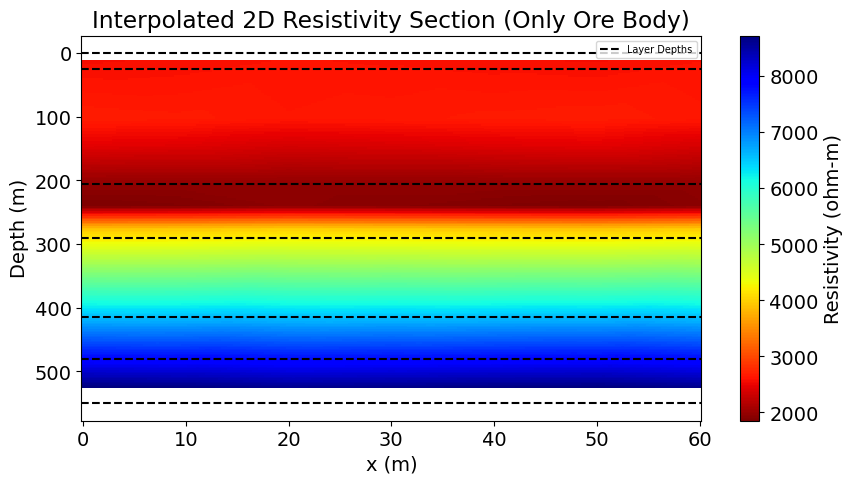

In [28]:
#Plotting results!
plt.figure(figsize=(10, 5))

plt.pcolormesh(XI, ZI, rho_section, cmap = 'jet_r')

#Plotting true layer depths
for i in layer_depth:
    plt.axhline(i, c = 'k', linestyle = '--')

plt.gca().invert_yaxis()
plt.colorbar(label='Resistivity (ohm-m)')
plt.xlabel('x (m)')
plt.ylabel('Depth (m)')
plt.title('Interpolated 2D Resistivity Section (Only Ore Body)')
plt.legend(fontsize = 7, labels =['Layer Depths'], loc = 1)
plt.show()